# 3) Learning Detection — Sequence Criterion (Strategy 1)

This notebook demonstrates the **Sequence Criterion** learning detection method (Figure 3, “Strategy 1” in the paper).



In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from Functions.standardize_dataset import standardize_dataset
from Functions.set_Beta_prior import set_priors
from Functions.update_strategy_posterior_probability import update_strategy_posterior_probability
from Functions.Summaries_of_Beta_distribution import summaries_of_Beta_Distribution
from Functions.plotSessionStructure import plotSessionStructure
from Functions.interpolate_null_trials import interpolate_null_trials

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import strategymodels

# Load + standardize
from config import data_path, prior_type, decay_rate, save_output_csv, strategy_name
from Functions.standardize_dataset import standardize_dataset

TestData = pd.read_csv(data_path)
TestData = standardize_dataset(TestData)
no_Trials = len(TestData)


In [2]:
# Load test data

no_Trials = len(TestData)

# Strategies shown in Figure 1
strategies = [
    "go_left",
    "go_right",
    "go_cued",
    "go_uncued",
    "win_stay_spatial",
    "lose_shift_cued",
    "lose_shift_spatial"
]

rule_strategies = ["go_left", "go_right", "go_cued"]


strategy_functions = {}
for s in strategies:
    try:
        strategy_functions[s] = getattr(strategymodels, s)
    except AttributeError:
        raise ValueError(f"Strategy '{s}' not found in strategymodels.")



TestData.head()

,TrialIndex,SessionIndex,TargetRule,Choice,CuePosition,Reward,RuleChangeTrials,NewSessionTrials
0,1,1,go right,right,left,yes,0,0
1,2,1,go right,right,right,yes,0,0
2,3,1,go right,left,left,no,0,0
3,4,1,go right,right,right,yes,0,0
4,5,1,go right,left,left,no,0,0


In [3]:
# Initialise storage
alpha0, beta0 = set_priors(prior_type) 

Output_collection = {}
event_totals = {}

for strategy in strategies:
    
    Output_collection[strategy] = pd.DataFrame(
        columns=[
            "Alpha", "Beta",
            "MAPprobability", "Precision",
            "Alpha_interpolated", "Beta_interpolated",
            "MAPprobability_interpolated", "Precision_interpolated"
        ]
    )
    
    event_totals[strategy] = {
        "success_total": 0,
        "failure_total": 0
    }

In [4]:
# Run Bayesian strategy analysis across trials

for trial in range(len(TestData)):
    
    rows_of_data = TestData.iloc[0:trial+1]
    
    for strategy in strategies:
        
        strategy_fcn = getattr(strategymodels, strategy)
        trial_type = strategy_fcn(rows_of_data)
        
        success_total, failure_total, Alpha, Beta = update_strategy_posterior_probability(
            trial_type,
            decay_rate,
            event_totals[strategy]["success_total"],
            event_totals[strategy]["failure_total"],
            alpha0,
            beta0
        )
        
        event_totals[strategy]["success_total"] = success_total
        event_totals[strategy]["failure_total"] = failure_total
        
        MAPprobability = summaries_of_Beta_Distribution(Alpha, Beta, "MAP")
        precision = summaries_of_Beta_Distribution(Alpha, Beta, "precision")
        
        this_trials_data = {
            "Alpha": Alpha,
            "Beta": Beta,
            "MAPprobability": MAPprobability,
            "Precision": precision
        }
        
        if trial > 0:
            previous_trials_data = Output_collection[strategy].iloc[trial-1]
        else:
            previous_trials_data = Output_collection[strategy]
        
        new_row_of_data = interpolate_null_trials(
            this_trials_data,
            previous_trials_data,
            alpha0,
            beta0
        )
        
        Output_collection[strategy] = pd.concat(
            [Output_collection[strategy], pd.DataFrame([new_row_of_data])],
            ignore_index=True
        )

/var/folders/1p/18jwl7x13xdgtw3zwr3q9zfr0000gn/T/ipykernel_48831/3955232189.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Output_collection[strategy] = pd.concat(


In [5]:
def detect_learning_per_block_targeted(Output_collection,
                                       block_starts,
                                       block_ends,
                                       block_target_strategies,
                                       chance_level=0.5,
                                       min_trials=5):
    """
    For each block, detect learning using the correct strategy for that block.
    min_trials: minimum remaining trials required to declare learning.
    """
    learning_trials = []

    for start, end, target_strategy in zip(block_starts, block_ends, block_target_strategies):

        MAP = Output_collection[target_strategy]["MAPprobability"].values
        block_map = MAP[start:end]

        lt = None
        for t in range(len(block_map)):
            remaining = block_map[t:]
            if len(remaining) >= min_trials and np.all(remaining > chance_level):
                lt = start + t
                break

        learning_trials.append(lt)

    return learning_trials
if "RuleChangeTrials" in TestData.columns:
    block_boundaries = list(TestData.index[TestData["RuleChangeTrials"] == 1])
else:
    block_boundaries = []

block_starts = [0] + block_boundaries
block_ends   = block_boundaries + [len(TestData)]

if "TargetRule" in TestData.columns:
    block_labels = [TestData.iloc[s]["TargetRule"] for s in block_starts]
else:
    block_labels = ["go right", "go to the lit arm", "go left", "go to the dark arm"][:len(block_starts)]

print("Block starts:", block_starts)
print("Block ends:  ", block_ends)
print("Block labels:", block_labels)


Block starts: [0, 170]
Block ends:   [170, 734]
Block labels: ['go right', 'go to the lit arm']


In [6]:
# -------------------------------------------------
# Map each task rule to the corresponding strategy
# -------------------------------------------------

rule_to_strategy = {
    "go right": "go_right",
    "Right Arm": "go_right",
    "go to the lit arm": "go_cued",
    "Lit Arm": "go_cued",
    "go left": "go_left",
    "Left Arm": "go_left",
    "go to the dark arm": "go_uncued",
    "Unlit Arm": "go_uncued"
}

block_target_strategies = [rule_to_strategy[label] for label in block_labels]
print("Block labels:", block_labels)
print("Strategy mapping:", block_target_strategies)

Block labels: ['go right', 'go to the lit arm']
Strategy mapping: ['go_right', 'go_cued']


In [7]:
chance_level = 0.5

learning_trials_blocks = detect_learning_per_block_targeted(
    Output_collection=Output_collection,
    block_starts=block_starts,
    block_ends=block_ends,
    block_target_strategies=block_target_strategies,
    chance_level=chance_level
)

print("Learning trials per block:", learning_trials_blocks)

Learning trials per block: [22, 693]


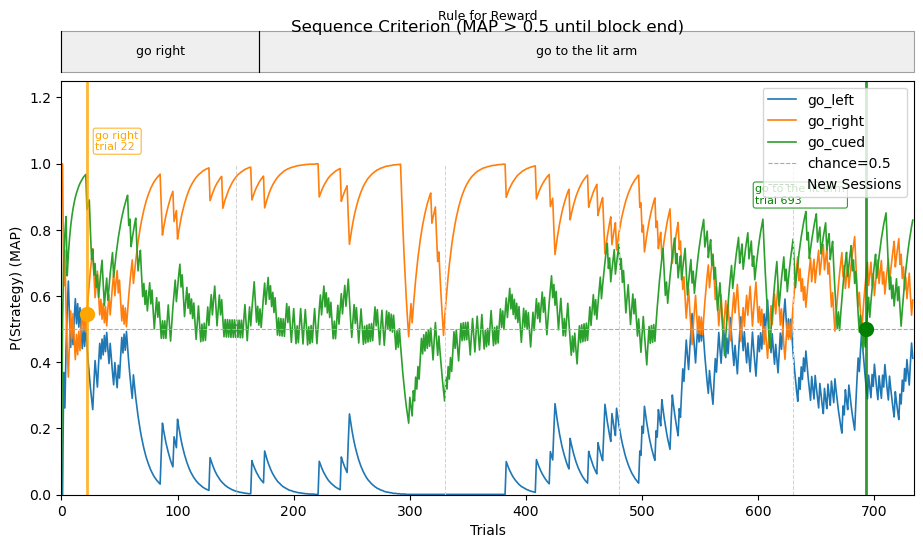

In [11]:
fig, ax = plt.subplots(figsize=(11, 6))

# MAP curves
for s in rule_strategies:
    ax.plot(Output_collection[s]["MAPprobability"], linewidth=1.2, label=s)

ax.axhline(y=chance_level, color="darkgrey", linestyle="--", linewidth=0.8, label="chance=0.5")

color_map = {
    "go_right": "orange",
    "go_cued": "green",
    "go_left": "blue",
    "go_uncued": "purple"
}

# Learning points — sadece tespit edilenler
detected = [
    (lt, strat, lbl)
    for lt, strat, lbl in zip(learning_trials_blocks, block_target_strategies, block_labels)
    if lt is not None
]
y_positions = [0.88 - i * 0.13 for i in range(len(detected))]

for (lt, target_strategy, block_label), y_frac in zip(detected, y_positions):
    color = color_map.get(target_strategy, "black")
    MAP_target = Output_collection[target_strategy]["MAPprobability"].values

    ax.axvline(lt, linewidth=2, color=color, alpha=0.8)
    ax.scatter(lt, MAP_target[lt], s=100, color=color, zorder=5)

    # Sağa yer yoksa sola kaydır
    x_offset = no_Trials * 0.01 if lt < no_Trials * 0.85 else -no_Trials * 0.13

    # x=data koordinatı, y=axes fraction (0-1) — sabit, kaymaz
    ax.text(
        lt + x_offset,
        y_frac,
        f"{block_label}\ntrial {lt}",
        fontsize=8,
        color=color,
        va="top",
        transform=ax.get_xaxis_transform(),
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8,
                  edgecolor=color, linewidth=0.8)
    )

# Rule band (show'dan önce)
try:
    plotSessionStructure(TestData, block_labels=block_labels)
except Exception as e:
    print("plotSessionStructure error:", e)

ax.set_xlabel("Trials")
ax.set_ylabel("P(Strategy) (MAP)")
ax.set_title("Sequence Criterion (MAP > 0.5 until block end)", pad=35)
ax.set_xlim(0, no_Trials)
ax.set_ylim(0, 1.25)

handles, labels_leg = ax.get_legend_handles_labels()
by_label = dict(zip(labels_leg, handles))
ax.legend(by_label.values(), by_label.keys())

plt.subplots_adjust(top=0.80)  # tight_layout yok — rule band için yer açık kalır
plt.show()


In [9]:
print("Block starts:", block_starts)
print("Block ends:", block_ends)
print("Block labels:", block_labels)


Block starts: [0, 170]
Block ends: [170, 734]
Block labels: ['go right', 'go to the lit arm']


# NEXT STEP
To compare all three learning criteria, run 4_Learning_Criteria_Comparison.ipynb